In [ ]:
# Install necessary libraries
!uv add pandas numpy matplotlib matplotlib-inline seaborn scikit-learn tensorflow "tensorflow[and-cuda]"

Resolved 68 packages in 10ms
Audited 67 packages in 0.02ms


In [ ]:
# Setup & Hardware Optimization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, roc_auc_score

# Use mixed precision for faster training on Tensor Cores
set_global_policy('mixed_float16')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Detected: {len(gpus)} GPU(s) active using Mixed Precision")
    except RuntimeError as e:
        print(e)

# Configuration
CONFIG = {
    'TIME_STEPS': 30,       # Longer context for LSTM
    'BATCH_SIZE': 2048,     # Large batch for 4090
    'EPOCHS': 100,
    'LATENT_DIM': 64,       # Bottleneck size
    'DROPOUT': 0.2,
    'LR': 0.001
}

In [ ]:

# Advanced Synthetic Data Generation (Time-Series)
def generate_synthetic_data(n_samples=200000):
    print(f"Generating {n_samples} samples of synthetic network traffic...")
    
    # Time vector
    t = np.linspace(0, 100 * np.pi, n_samples)
    
    # 1. Normal Traffic Patterns (Diurnal Sine Waves + Noise)
    # Simulates daily user usage cycles
    base_traffic = np.sin(t) * 5000 + 6000                    # Base Bytes
    packet_rate = np.sin(t) * 50 + 60                         # Packets/sec
    duration = np.abs(np.random.normal(5, 2, n_samples))      # Flow duration
    
    data = pd.DataFrame({
        'BytesSent': np.abs(base_traffic + np.random.normal(0, 500, n_samples)),
        'BytesReceived': np.abs(base_traffic * 1.5 + np.random.normal(0, 800, n_samples)),
        'PacketsSent': np.abs(packet_rate + np.random.normal(0, 10, n_samples)),
        'PacketsReceived': np.abs(packet_rate * 1.2 + np.random.normal(0, 10, n_samples)),
        'Duration': duration,
        'Protocol': np.random.choice([0, 1, 2], n_samples, p=[0.8, 0.15, 0.05]) # TCP, UDP, ICMP
    })
    
    # 2. Inject Anomalies (5% of data)
    n_anomalies = int(n_samples * 0.05)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    data['IsAnomaly'] = 0
    data.loc[anomaly_indices, 'IsAnomaly'] = 1
    
    # Type A: DoS Attack (Huge Packets, Tiny Duration)
    idx_a = anomaly_indices[:n_anomalies//2]
    data.loc[idx_a, 'PacketsSent'] = np.random.uniform(5000, 10000, len(idx_a))
    data.loc[idx_a, 'Duration'] = np.random.uniform(0.01, 0.1, len(idx_a))
    
    # Type B: Data Exfiltration (Huge Bytes Sent, Low Recv)
    idx_b = anomaly_indices[n_anomalies//2:]
    data.loc[idx_b, 'BytesSent'] = np.random.uniform(50000, 100000, len(idx_b))
    data.loc[idx_b, 'BytesReceived'] = np.random.uniform(100, 500, len(idx_b))

    return data

df = generate_synthetic_data()

Generating 200000 samples of synthetic network traffic...


In [ ]:
# Best Feature Selection & Engineering
def engineer_features(df):
    # 1. Log Transform Skewed Data (Crucial for Neural Nets)
    # Log1p handles 0 values safely: log(1+x)
    df['LogBytesSent'] = np.log1p(df['BytesSent'])
    df['LogBytesRecv'] = np.log1p(df['BytesReceived'])
    df['LogPacketsSent'] = np.log1p(df['PacketsSent'])
    df['LogPacketsRecv'] = np.log1p(df['PacketsReceived'])
    df['LogDuration'] = np.log1p(df['Duration'])
    
    # 2. Ratios (Behavioral Features)
    # Avoid division by zero
    df['ByteRatio'] = df['BytesSent'] / (df['BytesReceived'] + 1)
    df['PacketByteRatio'] = df['BytesSent'] / (df['PacketsSent'] + 1)
    
    # Features to use for training (Drop raw IPs/Ports as they confuse general models)
    features = ['LogBytesSent', 'LogBytesRecv', 'LogPacketsSent', 'LogPacketsRecv', 
                'LogDuration', 'ByteRatio', 'PacketByteRatio', 'Protocol']
    
    return df[features], df['IsAnomaly']

X, y = engineer_features(df)

# Split: Train ONLY on Normal data
normal_data = X[y == 0].values
anomaly_data = X[y == 1].values

# Scaler: Use PowerTransformer to make data Gaussian-like (Helps LSTM converge)
scaler = PowerTransformer(method='yeo-johnson')
X_normal_scaled = scaler.fit_transform(normal_data)
X_anomaly_scaled = scaler.transform(anomaly_data)

# Create Sequences (Rolling Window)
def create_sequences(data, time_steps):
    output = []
    for i in range(len(data) - time_steps):
        output.append(data[i : (i + time_steps)])
    return np.array(output)

# Train on Normal Sequences
X_train_seq = create_sequences(X_normal_scaled, CONFIG['TIME_STEPS'])

# Test on Mixed Sequences (Normal + Anomaly)
# We take a subset of normal + all anomalies for testing
test_normal_len = 10000
X_test_normal_seq = create_sequences(X_normal_scaled[-test_normal_len:], CONFIG['TIME_STEPS'])
X_test_anomaly_seq = create_sequences(X_anomaly_scaled, CONFIG['TIME_STEPS'])

X_test_seq = np.concatenate([X_test_normal_seq, X_test_anomaly_seq])
# Create labels: 0 for normal seq, 1 for anomaly seq
y_test_seq = np.concatenate([np.zeros(len(X_test_normal_seq)), np.ones(len(X_test_anomaly_seq))])

print(f"Training Shape: {X_train_seq.shape}")
print(f"Testing Shape: {X_test_seq.shape}")

Training Shape: (189970, 30, 8)
Testing Shape: (19940, 30, 8)


In [ ]:
# LSTM Autoencoder Model
def build_model(input_shape):
    model = models.Sequential([
        # Encoder
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(CONFIG['DROPOUT']),
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
        
        # Bottleneck
        layers.Dense(CONFIG['LATENT_DIM'], activation='relu'),
        
        # Decoder
        layers.RepeatVector(input_shape[0]),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(CONFIG['DROPOUT']),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.TimeDistributed(layers.Dense(input_shape[1]))
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LR']), 
                  loss='mae') # MAE is robust to outliers
    return model

model = build_model((X_train_seq.shape[1], X_train_seq.shape[2]))
model.summary()

# Training
history = model.fit(
    X_train_seq, X_train_seq,
    epochs=CONFIG['EPOCHS'],
    batch_size=CONFIG['BATCH_SIZE'],
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ],
    verbose=1
)

I0000 00:00:1769092997.355960 3664727 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22138 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       140,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 30, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 30, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 8)          │         2,056 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,168 (2.46 MB)

 Trainable params: 644,168 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2026-01-22 20:28:20.406947: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-01-22 20:28:20.465210: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.4285 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.3888 - val_loss: 0.3844 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.3847 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.3821 - val_loss: 0.3801 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.3796 - val_loss: 0.3767 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.3775 - val_loss: 0.3744 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.3753 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.3739 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 9/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.3714 - val_loss: 0.3673 - learning_rate: 0.0010
Epoch 10/100
84/84 ━━━

In [15]:
# Cell 5: Detection & Thresholding
# 1. Calculate reconstruction error (MAE)
pred_test = model.predict(X_test_seq, batch_size=CONFIG['BATCH_SIZE'])
mae_per_sample = np.mean(np.abs(pred_test - X_test_seq), axis=(1, 2))

# 2. Determine Threshold (Dynamic)
# We calculate the error on the Training set (Normal) and set threshold at 99th percentile
pred_train = model.predict(X_train_seq, batch_size=CONFIG['BATCH_SIZE'])
train_mae_loss = np.mean(np.abs(pred_train - X_train_seq), axis=(1, 2))
threshold = np.percentile(train_mae_loss, 99) # Set threshold at 99% confidence

print(f"Reconstruction Error Threshold: {threshold}")

# 3. Classify
predictions = (mae_per_sample > threshold).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Reconstruction Error Threshold: 0.5275290731008512


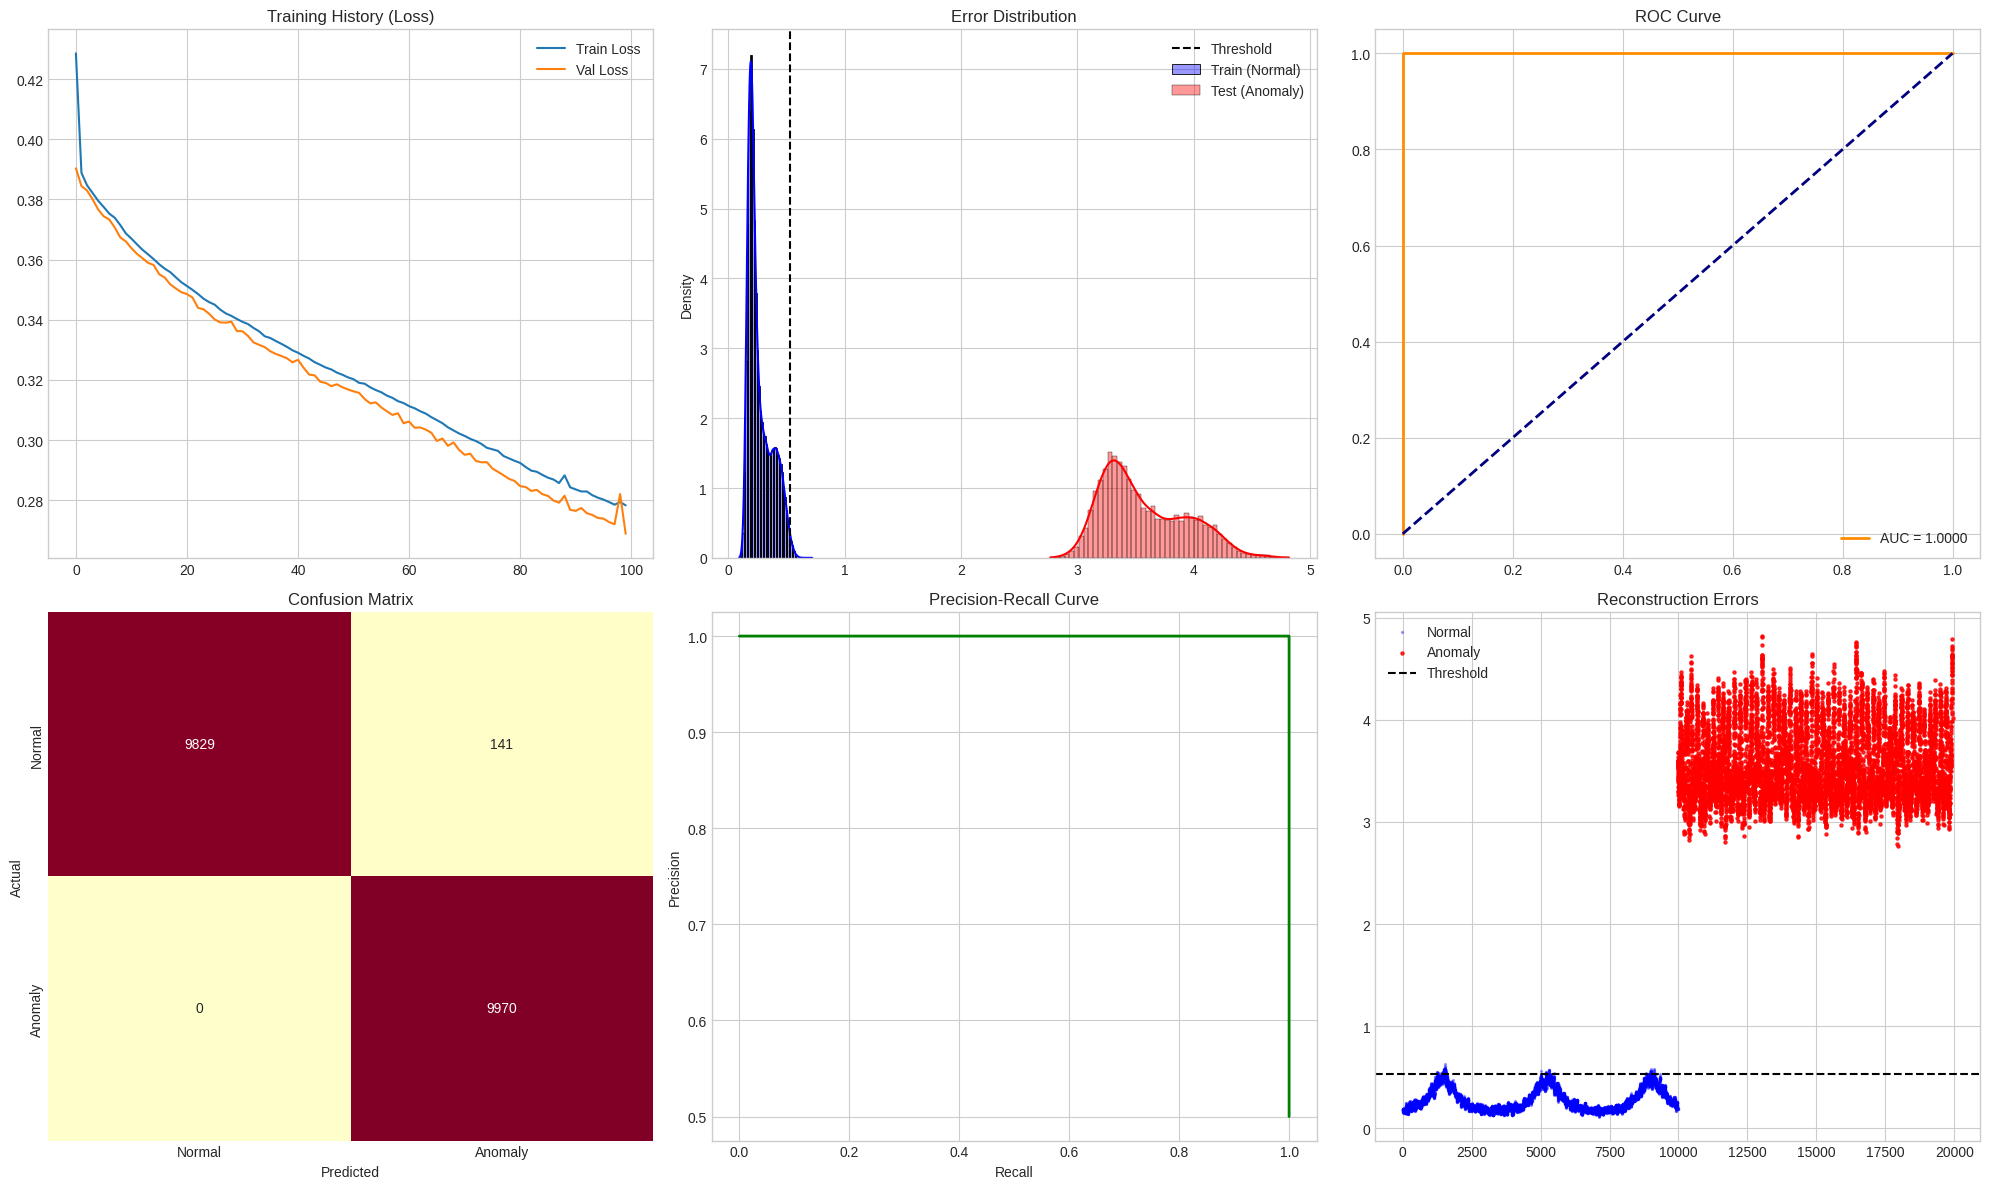


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      9970
     Anomaly       0.99      1.00      0.99      9970

    accuracy                           0.99     19940
   macro avg       0.99      0.99      0.99     19940
weighted avg       0.99      0.99      0.99     19940



In [ ]:
# Visualization (Exact Replication of Your Image)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# A. Training History
axes[0,0].plot(history.history['loss'], label='Train Loss')
axes[0,0].plot(history.history['val_loss'], label='Val Loss')
axes[0,0].set_title('Training History (Loss)')
axes[0,0].legend()

# B. Error Distribution
sns.histplot(train_mae_loss, bins=50, kde=True, color='blue', label='Train (Normal)', ax=axes[0,1], stat='density', alpha=0.4)
sns.histplot(mae_per_sample[y_test_seq==1], bins=50, kde=True, color='red', label='Test (Anomaly)', ax=axes[0,1], stat='density', alpha=0.4)
axes[0,1].axvline(threshold, color='k', linestyle='--', label='Threshold')
axes[0,1].set_title('Error Distribution')
axes[0,1].legend()

# C. ROC Curve
fpr, tpr, _ = roc_curve(y_test_seq, mae_per_sample)
roc_auc = auc(fpr, tpr)
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend()

# D. Confusion Matrix
cm = confusion_matrix(y_test_seq, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,0], cbar=False)
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xticklabels(['Normal', 'Anomaly'])
axes[1,0].set_yticklabels(['Normal', 'Anomaly'])

# E. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_seq, mae_per_sample)
axes[1,1].plot(recall, precision, lw=2, color='green')
axes[1,1].set_title('Precision-Recall Curve')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')

# F. Reconstruction Errors Scatter
indices = np.arange(len(mae_per_sample))
axes[1,2].scatter(indices[y_test_seq==0], mae_per_sample[y_test_seq==0], s=2, c='blue', label='Normal', alpha=0.3)
axes[1,2].scatter(indices[y_test_seq==1], mae_per_sample[y_test_seq==1], s=5, c='red', label='Anomaly', alpha=0.8)
axes[1,2].axhline(threshold, color='k', linestyle='--', label='Threshold')
axes[1,2].set_title('Reconstruction Errors')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('results-test-re3.png', dpi=300)
plt.show()

# Print Metrics
print("\nClassification Report:")
print(classification_report(y_test_seq, predictions, target_names=['Normal', 'Anomaly']))


--- Testing Scenario: NORMAL ---
Reconstruction Error (MAE): 0.1509
Threshold: 0.5275
Result: NORMAL TRAFFIC

--- Testing Scenario: DOS_ATTACK ---
Reconstruction Error (MAE): 7.0037
Threshold: 0.5275
Result: ANOMALY DETECTED

--- Testing Scenario: EXFILTRATION ---
Reconstruction Error (MAE): 23.5500
Threshold: 0.5275
Result: ANOMALY DETECTED

✅ SUCCESS: The model can clearly distinguish attacks from normal traffic.

  GENERATING PERFORMANCE REPORT...

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       100
     Anomaly       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



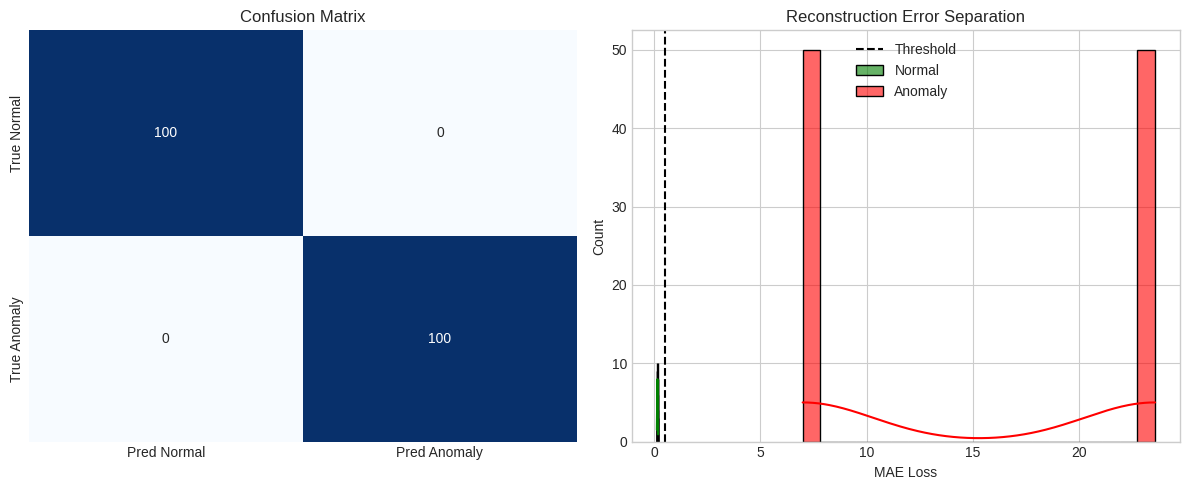

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. DATA GENERATION & PREPROCESSING
# ==========================================

def generate_custom_scenario(scenario_type='normal'):
    """Generates a burst of 30 data points representing specific network behavior."""
    rows = []
    for _ in range(CONFIG['TIME_STEPS']):
        if scenario_type == 'normal':
            # Scenario: Standard browsing (low bytes, balanced)
            data = {
                'BytesSent': np.random.normal(5000, 500),
                'BytesReceived': np.random.normal(6000, 500),
                'PacketsSent': np.random.normal(50, 5),
                'PacketsReceived': np.random.normal(55, 5),
                'Duration': np.random.normal(2.0, 0.5),
                'Protocol': 0 
            }
        elif scenario_type == 'dos_attack':
            # Scenario: DoS (High packets, tiny duration, no receive)
            data = {
                'BytesSent': np.random.normal(100, 10),
                'BytesReceived': 0,
                'PacketsSent': np.random.normal(20000, 500),
                'PacketsReceived': 0,
                'Duration': 0.001,
                'Protocol': 1 
            }
        elif scenario_type == 'exfiltration':
            # Scenario: Data Theft (Huge data sent, tiny data received)
            data = {
                'BytesSent': np.random.normal(50000000, 10000),
                'BytesReceived': np.random.normal(200, 10),
                'PacketsSent': np.random.normal(5000, 100),
                'PacketsReceived': np.random.normal(100, 10),
                'Duration': np.random.normal(30.0, 2.0),
                'Protocol': 0 
            }
        rows.append(data)
    return pd.DataFrame(rows)

def preprocess_sequence(df, scaler):
    """Applies feature engineering and scaling to a raw DataFrame."""
    # Feature Engineering
    df['LogBytesSent'] = np.log1p(df['BytesSent'])
    df['LogBytesRecv'] = np.log1p(df['BytesReceived'])
    df['LogPacketsSent'] = np.log1p(df['PacketsSent'])
    df['LogPacketsRecv'] = np.log1p(df['PacketsReceived'])
    df['LogDuration'] = np.log1p(df['Duration'])
    
    df['ByteRatio'] = df['BytesSent'] / (df['BytesReceived'] + 1)
    df['PacketByteRatio'] = df['BytesSent'] / (df['PacketsSent'] + 1)
    
    features = ['LogBytesSent', 'LogBytesRecv', 'LogPacketsSent', 'LogPacketsRecv', 
                'LogDuration', 'ByteRatio', 'PacketByteRatio', 'Protocol']
    
    X_raw = df[features].values
    X_scaled = scaler.transform(X_raw)
    
    return X_scaled.reshape(1, CONFIG['TIME_STEPS'], len(features))

# ==========================================
# 2. QUICK CHECK (Text Output)
# ==========================================

def test_custom_input(model, scaler, threshold, scenario_type):
    print(f"\n--- Testing Scenario: {scenario_type.upper()} ---")
    
    # 1. Generate & Process
    df = generate_custom_scenario(scenario_type)
    X_seq = preprocess_sequence(df, scaler)
    
    # 2. Predict
    reconstruction = model.predict(X_seq, verbose=0)
    mae = np.mean(np.abs(reconstruction - X_seq))
    
    # 3. Result
    status = "ANOMALY DETECTED" if mae > threshold else "NORMAL TRAFFIC"
    
    print(f"Reconstruction Error (MAE): {mae:.4f}")
    print(f"Threshold: {threshold:.4f}")
    print(f"Result: {status}")
    
    return mae

# ==========================================
# 3. DEEP PERFORMANCE REPORT (Graphs & Metrics)
# ==========================================

def generate_evaluation_batch(n_normal=50, n_dos=25, n_exfil=25):
    """Generates a batch of 100 sequences for statistical testing."""
    X_list = []
    y_true = [] 
    
    # Generate Normal
    for _ in range(n_normal):
        X_list.append(preprocess_sequence(generate_custom_scenario('normal'), scaler))
        y_true.append(0)
        
    # Generate DoS
    for _ in range(n_dos):
        X_list.append(preprocess_sequence(generate_custom_scenario('dos_attack'), scaler))
        y_true.append(1)
        
    # Generate Exfiltration
    for _ in range(n_exfil):
        X_list.append(preprocess_sequence(generate_custom_scenario('exfiltration'), scaler))
        y_true.append(1)
        
    return np.vstack(X_list), np.array(y_true)

def evaluate_performance(model, scaler, threshold):
    print("\n" + "="*40)
    print("  GENERATING PERFORMANCE REPORT...")
    print("="*40)
    
    # Generate Batch Data
    X_test, y_true = generate_evaluation_batch(n_normal=100, n_dos=50, n_exfil=50)
    
    # Predict
    X_pred = model.predict(X_test, verbose=0)
    mae_loss = np.mean(np.abs(X_pred - X_test), axis=(1,2))
    y_pred = [1 if error > threshold else 0 for error in mae_loss]
    
    # --- Text Report ---
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))
    
    # --- Graphs ---
    plt.figure(figsize=(12, 5))
    
    # Confusion Matrix 
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Normal', 'Pred Anomaly'],
                yticklabels=['True Normal', 'True Anomaly'])
    plt.title('Confusion Matrix')
    
    # Error Distribution 
    plt.subplot(1, 2, 2)
    sns.histplot(mae_loss[y_true==0], bins=20, color='green', label='Normal', alpha=0.6, kde=True)
    sns.histplot(mae_loss[y_true==1], bins=20, color='red', label='Anomaly', alpha=0.6, kde=True)
    plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
    plt.title('Reconstruction Error Separation')
    plt.xlabel('MAE Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================

# A. Run Single Instance Checks (The text you like)
error_normal = test_custom_input(model, scaler, threshold, 'normal')
error_dos = test_custom_input(model, scaler, threshold, 'dos_attack')
error_exfil = test_custom_input(model, scaler, threshold, 'exfiltration')

if error_dos > error_normal * 2:
    print("\n✅ SUCCESS: The model can clearly distinguish attacks from normal traffic.")
else:
    print("\n❌ FAILURE: The model cannot distinguish the patterns.")

# B. Run Full Performance Report (The graphs & metrics)
evaluate_performance(model, scaler, threshold)